<a href="https://colab.research.google.com/github/mmerazItam/ClasificadorTumores/blob/main/ClasificacionTumores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
pip install tensorflow keras opencv-python numpy matplotlib seaborn scikit-learn pandas

In [12]:
!pip install kaggle

### EDA

1.  Sube tu archivo `kaggle.json` (obtenido de tu cuenta de Kaggle) a tu entorno de Colab.
2.  Mueve el archivo a la ubicación correcta y asigna los permisos adecuados.

In [13]:
import os
from google.colab import files

# Crea el directorio .kaggle si no existe
!mkdir -p ~/.kaggle

# Sube el archivo kaggle.json. Una ventana de selección de archivos aparecerá.
# Debes seleccionar el archivo kaggle.json que descargaste de Kaggle.
print("Por favor, selecciona el archivo 'kaggle.json' que descargaste de Kaggle:")
files.upload()

# Mueve el archivo kaggle.json al directorio correcto
!mv kaggle.json ~/.kaggle/

# Establece los permisos correctos para el archivo kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("\n¡Configuración de Kaggle completada! Ahora puedes usar la API de Kaggle.")

Por favor, selecciona el archivo 'kaggle.json' que descargaste de Kaggle:


Saving kaggle.json to kaggle.json

¡Configuración de Kaggle completada! Ahora puedes usar la API de Kaggle.


In [2]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 197MB/s]



### Paso 1: Descomprimir el dataset de imágenes

In [3]:
import os

zip_file_name = '/content/brain-tumor-mri-dataset.zip'
dataset_dir = '/content/brain_tumor_dataset'

# Verificar si el archivo zip existe
if os.path.exists(zip_file_name):
    print(f"Archivo '{zip_file_name}' encontrado. Descomprimiendo...")
    !unzip -q {zip_file_name} -d {dataset_dir}
    print(f"Dataset descomprimido en la carpeta '{dataset_dir}'.")
    # Verificar si el directorio del dataset se creó después de la descompresión
    if not os.path.exists(dataset_dir):
        print(f"Advertencia: La carpeta '{dataset_dir}' no se creó después de la descompresión. Puede haber un problema con el comando unzip.")
else:
    print(f"Error: El archivo '{zip_file_name}' no se encontró. Por favor, asegúrate de que el dataset se haya descargado correctamente. Puedes intentar ejecutar la celda anterior de descarga de Kaggle de nuevo (dB4bvvNm66tC).")

Archivo '/content/brain-tumor-mri-dataset.zip' encontrado. Descomprimiendo...
Dataset descomprimido en la carpeta '/content/brain_tumor_dataset'.


### Paso 2: Explorar la estructura de carpetas del dataset

In [4]:
# Listar el contenido de la carpeta principal del dataset
import os

dataset_path = 'brain_tumor_dataset'
print(f"Contenido de '{dataset_path}':")
print(os.listdir(dataset_path))

# Listar el contenido de las subcarpetas para entender la estructura
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]: # Mostrar solo los primeros 3 archivos por carpeta para no saturar
        print(f'{subindent}{f}')
    if len(files) > 3:
        print(f'{subindent}...')
    if not files and not dirs: # If folder is empty
        print(f'{subindent}(empty)')

Contenido de 'brain_tumor_dataset':
['Testing', 'Training']
brain_tumor_dataset/
    Testing/
        pituitary/
            Te-pi_217.jpg
            Te-pi_122.jpg
            Te-pi_272.jpg
            ...
        notumor/
            Te-no_378.jpg
            Te-no_346.jpg
            Te-no_354.jpg
            ...
        meningioma/
            Te-me_84.jpg
            Te-aug-me_91.jpg
            Te-me_39.jpg
            ...
        glioma/
            Te-gl_295.jpg
            Te-gl_140.jpg
            Te-gl_68.jpg
            ...
    Training/
        pituitary/
            Tr-pi_610.jpg
            Tr-pi_177.jpg
            Tr-pi_20.jpg
            ...
        notumor/
            Tr-no_453.jpg
            Tr-no_1346.jpg
            Tr-no_706.jpg
            ...
        meningioma/
            Tr-me_36.jpg
            Tr-me_959.jpg
            Tr-me_756.jpg
            ...
        glioma/
            Tr-gl_363.jpg
            Tr-gl_405.jpg
            Tr-gl_1228.jpg
            

### Paso 3: Análisis de la distribución de clases (Barplot)

/tmp/ipykernel_13455/2637957127.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df_class_counts, palette='viridis')


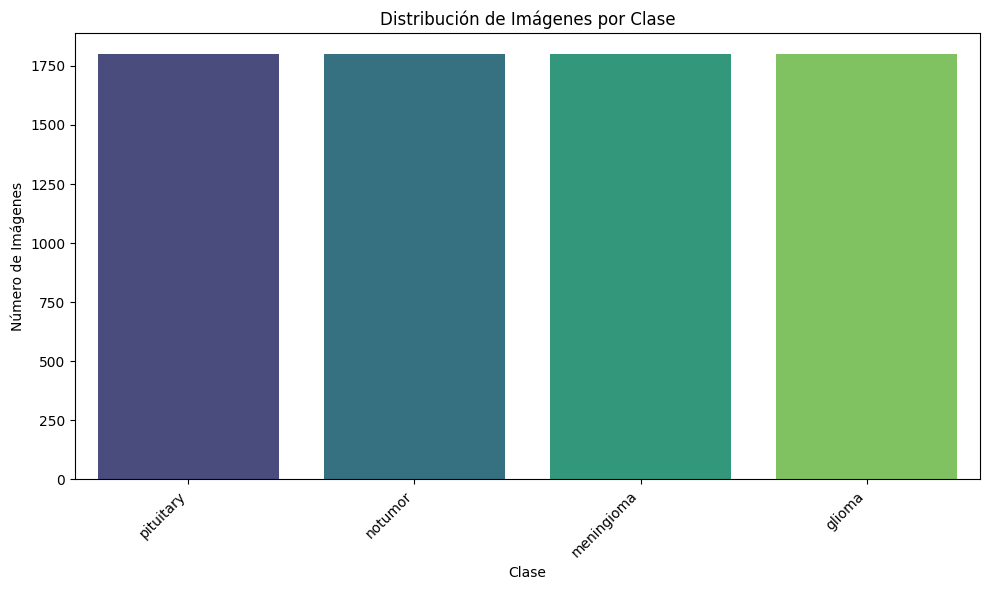

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = '/content/brain_tumor_dataset'

def count_images_per_class(base_path):
    class_counts = {}
    for subdir in os.listdir(base_path):
        if os.path.isdir(os.path.join(base_path, subdir)):
            for class_name in os.listdir(os.path.join(base_path, subdir)):
                class_path = os.path.join(base_path, subdir, class_name)
                if os.path.isdir(class_path):
                    num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                    class_counts[class_name] = class_counts.get(class_name, 0) + num_images
    return class_counts

# Obtener el conteo de imágenes por clase en todo el dataset
all_class_counts = count_images_per_class(dataset_path)

# Crear un DataFrame para facilitar la visualización
df_class_counts = pd.DataFrame(list(all_class_counts.items()), columns=['Class', 'Count'])

# Ordenar por conteo para una mejor visualización
df_class_counts = df_class_counts.sort_values(by='Count', ascending=False)

# Graficar la distribución de clases
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=df_class_counts, palette='viridis')
plt.title('Distribución de Imágenes por Clase')
plt.xlabel('Clase')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Paso 4: Visualización de ejemplos aleatorios de imágenes por clase

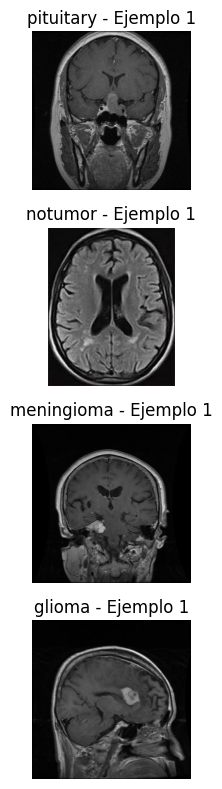

In [6]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Define dataset_path here to ensure it's always available
dataset_path = '/content/brain_tumor_dataset'

def get_random_training_image_paths_per_class(base_path, num_examples=1):
    """
    Collects a specified number of random image paths for each class
    ONLY from the 'Training' subdirectory.
    """
    training_image_paths_per_class = {}
    training_dir = os.path.join(base_path, 'Training')

    if not os.path.isdir(training_dir):
        # This is a critical check. If this fails, the dataset is not structured as expected or not present.
        print(f"Error: Training directory not found at {training_dir}. Please ensure the dataset is unzipped correctly.")
        return {}

    # List all entries in the training directory, then filter for actual directories (classes)
    class_entries = os.listdir(training_dir)
    class_dirs = [d for d in class_entries if os.path.isdir(os.path.join(training_dir, d))]

    if not class_dirs:
        print(f"Error: No class subdirectories found in {training_dir}. Expected class folders like 'glioma', 'notumor', etc.")
        return {}

    for class_name in class_dirs:
        class_path = os.path.join(training_dir, class_name)

        all_images_in_class = []
        # Filter for common image extensions, case-insensitively
        for f in os.listdir(class_path):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_images_in_class.append(os.path.join(class_path, f))

        if not all_images_in_class:
            print(f"Warning: No valid image files found in class directory {class_path} matching ['.jpg', '.jpeg', '.png'].")
            continue # Skip this class if no images were found

        random.shuffle(all_images_in_class)
        # Take up to num_examples, or fewer if not enough images
        training_image_paths_per_class[class_name] = all_images_in_class[:num_examples]

    return training_image_paths_per_class

# Obtener rutas de imágenes aleatorias solo del conjunto de entrenamiento
random_images = get_random_training_image_paths_per_class(dataset_path, num_examples=1)

# Graficar los ejemplos aleatorios
num_classes = len(random_images)
num_examples_per_class_to_plot = 1 # Always 1 as requested

if num_classes == 0:
    print("No images found to display for any class in the Training set. Please check previous error messages or ensure the dataset is correctly structured.")
else:
    # Dynamically adjust figsize based on the number of classes
    fig_height = max(4, num_classes * 2) # Minimum height, then 2 inches per class for potentially many classes
    fig, axes = plt.subplots(num_classes, num_examples_per_class_to_plot, figsize=(6 * num_examples_per_class_to_plot, fig_height))

    # Ensure 'axes' is always a 2D array for consistent indexing
    if num_classes == 1 and num_examples_per_class_to_plot == 1:
        axes = np.array([[axes]])
    elif num_classes == 1: # Row is 1, cols > 1 (should not happen if num_examples_per_class_to_plot is 1)
        axes = np.expand_dims(axes, axis=0)
    elif num_examples_per_class_to_plot == 1: # Rows > 1, col is 1
        axes = np.expand_dims(axes, axis=1)

    for i, (class_name, paths) in enumerate(random_images.items()):
        # Ensure we don't try to access out of bounds for axes if num_examples_per_class_to_plot is somehow mismatched with paths
        # This check is mostly for robustness, paths should always have num_examples_per_class_to_plot elements or fewer
        for j in range(num_examples_per_class_to_plot):
            if j < len(paths): # Check if there is an image path for this slot
                img_path = paths[j]
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    axes[i, j].imshow(img)
                    axes[i, j].set_title(f'{class_name} - Ejemplo {j+1}')
                else:
                    axes[i, j].text(0.5, 0.5, f'Error al cargar {class_name}', horizontalalignment='center', verticalalignment='center', transform=axes[i, j].transAxes, fontsize=10, color='red')
                    axes[i, j].set_title(f'{class_name} - Error')
                axes[i, j].axis('off')
            else: # If there are fewer images than num_examples_per_class_to_plot for this class
                axes[i, j].axis('off') # Hide empty subplot

    plt.tight_layout()
    plt.show()

### Paso 5: Histograma de intensidades por clase

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = '/content/brain_tumor_dataset'

def plot_intensity_histograms(base_path, num_images_per_class=50):
    class_names = [d for d in os.listdir(os.path.join(base_path, 'Training')) if os.path.isdir(os.path.join(base_path, 'Training', d))]

    fig, axes = plt.subplots(len(class_names), 1, figsize=(10, 4 * len(class_names)))
    if len(class_names) == 1: # Handle case with a single class to avoid indexing error on axes
        axes = [axes]

    for i, class_name in enumerate(class_names):
        all_intensities = []
        # Collect images from both Training and Testing for a more comprehensive histogram
        for subdir in ['Training', 'Testing']:
            class_path = os.path.join(base_path, subdir, class_name)
            if os.path.isdir(class_path):
                image_files = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

                # Sample a subset of images for efficiency
                sampled_images = random.sample(image_files, min(len(image_files), num_images_per_class))

                for img_path in sampled_images:
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Leer en escala de grises
                    if img is not None:
                        all_intensities.extend(img.flatten())

        if all_intensities:
            sns.histplot(all_intensities, bins=256, ax=axes[i], color='skyblue', kde=True)
            axes[i].set_title(f'Histograma de Intensidad para la Clase: {class_name}')
            axes[i].set_xlabel('Intensidad de Píxel')
            axes[i].set_ylabel('Frecuencia')
            axes[i].set_xlim(0, 255)
        else:
            axes[i].set_title(f'No se encontraron imágenes para la clase: {class_name}')

    plt.tight_layout()
    plt.show()

plot_intensity_histograms(dataset_path)


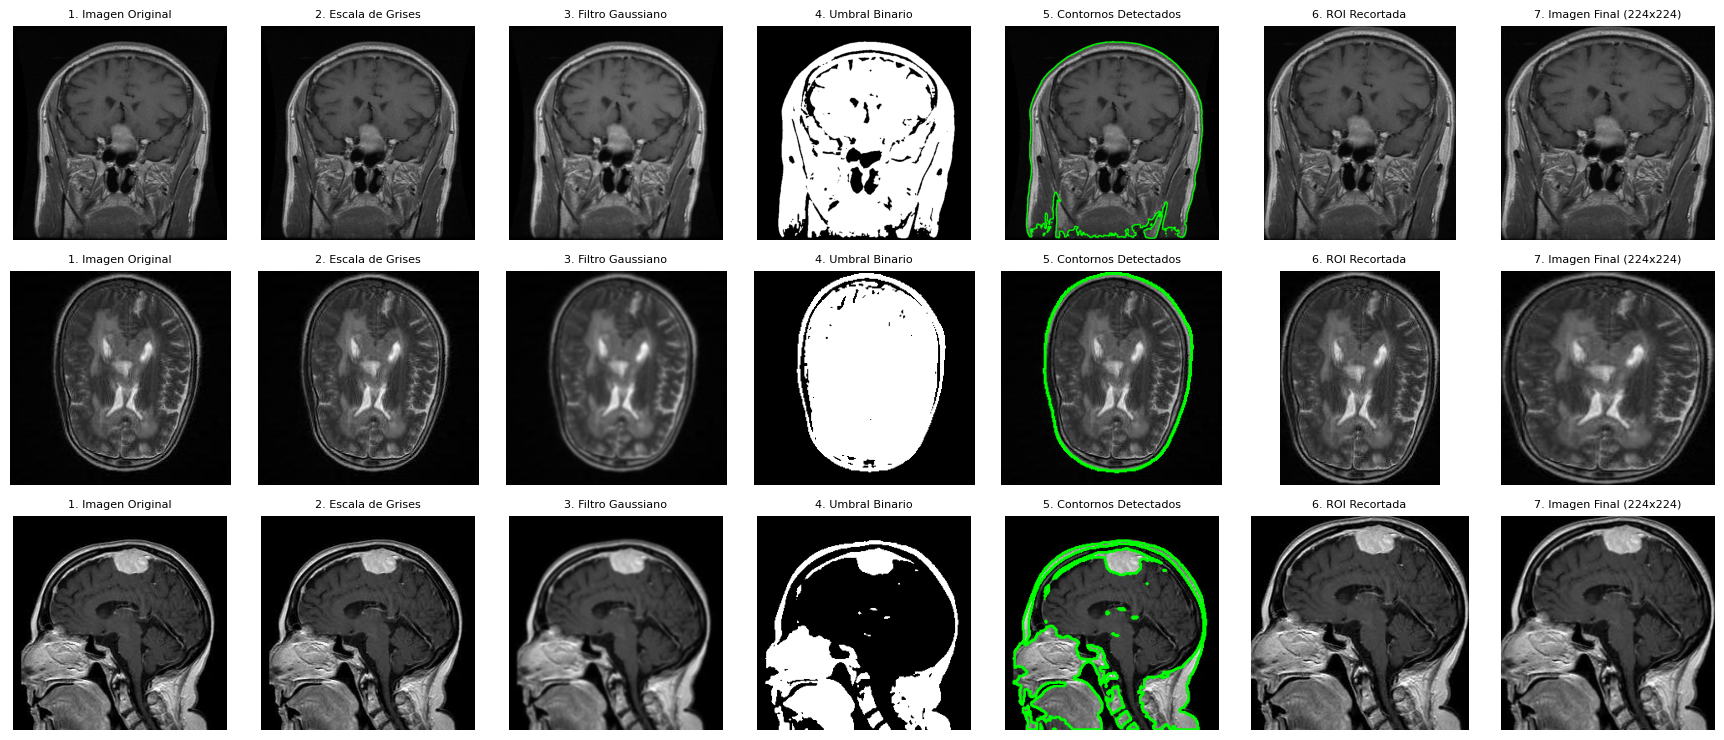

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

dataset_path = '/content/brain_tumor_dataset'

def preprocess_and_visualize_steps(image_path, target_size=(224, 224)):
    # 1. Leer imagen original
    original_bgr = cv2.imread(image_path)
    if original_bgr is None:
        print(f"Error: No se pudo cargar la imagen en {image_path}")
        return []
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    # 2. Convertir a escala de grises
    gray_image = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)

    # 3. Aplicar normalización de intensidad (simple min-max a 0-255)
    normalized_gray = cv2.normalize(gray_image, None, 0, 255, cv2.NORM_MINMAX)

    # 4. Aplicar filtro Gaussiano
    gaussian_blurred = cv2.GaussianBlur(normalized_gray, (5, 5), 0)

    # 5. Aplicar umbralización binaria (usando Otsu's method)
    _, binary_threshold = cv2.threshold(gaussian_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 6. Detectar contornos
    # Usar una copia porque findContours modifica la imagen de entrada
    contours, _ = cv2.findContours(binary_threshold.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Crear una imagen para dibujar los contornos (para visualización)
    contours_drawn = original_rgb.copy()
    if contours:
        cv2.drawContours(contours_drawn, contours, -1, (0, 255, 0), 2) # Dibuja en verde

    # 7. Recortar región de interés (ROI) para visualización
    roi_cropped_rgb = None
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        roi_cropped_rgb = original_rgb[y:y+h, x:x+w]
    else:
        # Fallback: si no hay contornos, usa la imagen original como ROI para visualización
        roi_cropped_rgb = original_rgb.copy()
        print(f"Advertencia: No se encontraron contornos para {image_path}, usando la imagen original como ROI para visualización de recorte.")

    # 8. y 9. Redimensionar y convertir a 3 canales para la entrada al modelo
    # Primero, recortar la imagen en escala de grises
    roi_cropped_gray = None
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        roi_cropped_gray = gray_image[y:y+h, x:x+w]
    else:
        # Fallback: si no hay contornos, usa la imagen en escala de grises original
        roi_cropped_gray = gray_image.copy()
        print(f"Advertencia: No se encontraron contornos para {image_path}, usando la imagen original (gris) para el paso final.")

    # Redimensionar la ROI en escala de grises
    resized_gray_for_model = cv2.resize(roi_cropped_gray, target_size)

    # Convertir a 3 canales (RGB para matplotlib)
    final_3_channel_for_model = cv2.cvtColor(resized_gray_for_model, cv2.COLOR_GRAY2RGB)

    return [
        original_rgb,
        gray_image,
        gaussian_blurred,
        binary_threshold,
        contours_drawn,
        roi_cropped_rgb,
        final_3_channel_for_model
    ]

# Función para obtener rutas de imágenes aleatorias
def get_random_image_paths(base_path, num_samples=3):
    image_paths = []
    training_dir = os.path.join(base_path, 'Training')
    if not os.path.isdir(training_dir):
        print(f"Error: Directorio de entrenamiento no encontrado en {training_dir}")
        return []

    class_dirs = [d for d in os.listdir(training_dir) if os.path.isdir(os.path.join(training_dir, d))]
    if not class_dirs:
        print(f"Error: No se encontraron subdirectorios de clases en {training_dir}")
        return []

    for class_name in class_dirs:
        class_path = os.path.join(training_dir, class_name)
        images = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            image_paths.append(random.choice(images))
            if len(image_paths) >= num_samples:
                break
    return image_paths

# Seleccionar 3 imágenes aleatorias para la demostración
num_display_images = 3
example_image_paths = get_random_image_paths(dataset_path, num_samples=num_display_images)

if not example_image_paths:
    print(f"No se encontraron imágenes de ejemplo en '{dataset_path}' para demostrar el preprocesamiento. Por favor, asegúrate de que el dataset esté descomprimido y con la estructura esperada.")
else:
    titles = [
        "1. Imagen Original",
        "2. Escala de Grises",
        "3. Filtro Gaussiano",
        "4. Umbral Binario",
        "5. Contornos Detectados",
        "6. ROI Recortada",
        "7. Imagen Final (224x224)"
    ]

    num_steps = len(titles)

    # Ajustar el tamaño de la figura dinámicamente
    fig, axes = plt.subplots(num_display_images, num_steps, figsize=(num_steps * 2.5, num_display_images * 2.5))

    # Asegurarse de que 'axes' sea siempre un array 2D para una indexación consistente
    if num_display_images == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, img_path in enumerate(example_image_paths):
        processed_images = preprocess_and_visualize_steps(img_path)
        if not processed_images:
            # Si hubo un error en el procesamiento de esta imagen, rellenar con subtramas vacías o marcadores de error
            for j in range(num_steps):
                ax = axes[i, j]
                ax.text(0.5, 0.5, 'Error en procesamiento', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=10, color='red')
                ax.set_title(titles[j], fontsize=8)
                ax.axis('off')
            continue

        for j, img_step in enumerate(processed_images):
            ax = axes[i, j]
            # Manejar imágenes en escala de grises para la visualización
            # Las imágenes de OpenCV son NumPy arrays. Si tienen 2 dimensiones o la 3ra dimensión es 1, son escala de grises.
            if len(img_step.shape) == 2 or (len(img_step.shape) == 3 and img_step.shape[2] == 1):
                ax.imshow(img_step, cmap='gray')
            else:
                ax.imshow(img_step)
            ax.set_title(titles[j], fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    plt.show()


### Paso 6: Aplicar el Preprocesamiento a todo el Dataset y Guardar las Imágenes

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm # Para mostrar una barra de progreso

# Definir el tamaño final de las imágenes
target_size = (224, 224)

def preprocess_image(image_path, target_size=(224, 224)):
    """
    Aplica el flujo de preprocesamiento a una sola imagen y devuelve la imagen final.
    """
    original_bgr = cv2.imread(image_path)
    if original_bgr is None:
        # print(f"Advertencia: No se pudo cargar la imagen en {image_path}, saltando.")
        return None

    # Convertir a escala de grises
    gray_image = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)

    # Aplicar normalización de intensidad (simple min-max a 0-255)
    normalized_gray = cv2.normalize(gray_image, None, 0, 255, cv2.NORM_MINMAX)

    # Aplicar filtro Gaussiano
    gaussian_blurred = cv2.GaussianBlur(normalized_gray, (5, 5), 0)

    # Aplicar umbralización binaria (usando Otsu's method)
    _, binary_threshold = cv2.threshold(gaussian_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Detectar contornos
    contours, _ = cv2.findContours(binary_threshold.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    roi_cropped_gray = None
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        # Asegurarse de que las coordenadas sean válidas para evitar errores de recorte
        y = max(0, y)
        x = max(0, x)
        h = min(h, gray_image.shape[0] - y)
        w = min(w, gray_image.shape[1] - x)
        if w > 0 and h > 0:
            roi_cropped_gray = gray_image[y:y+h, x:x+w]
        else:
            # print(f"Advertencia: Contorno inválido o demasiado pequeño para {image_path}. Usando imagen completa.")
            roi_cropped_gray = gray_image.copy()
    else:
        # print(f"Advertencia: No se encontraron contornos para {image_path}, usando la imagen original (gris).")
        roi_cropped_gray = gray_image.copy()

    # Redimensionar la ROI en escala de grises
    resized_gray = cv2.resize(roi_cropped_gray, target_size)

    # Convertir a 3 canales (RGB) para la entrada al modelo
    final_3_channel_image = cv2.cvtColor(resized_gray, cv2.COLOR_GRAY2RGB)

    return final_3_channel_image

# Rutas de entrada y salida
input_dataset_path = '/content/brain_tumor_dataset'
output_dataset_path = '/content/preprocessed_brain_tumor_dataset'

# Crear el directorio de salida si no existe
os.makedirs(output_dataset_path, exist_ok=True)

# Listas para almacenar estadísticas
processed_count = 0
skipped_count = 0

# Iterar sobre las carpetas 'Training' y 'Testing'
for subset in ['Training', 'Testing']:
    input_subset_path = os.path.join(input_dataset_path, subset)
    output_subset_path = os.path.join(output_dataset_path, subset)
    os.makedirs(output_subset_path, exist_ok=True)

    # Iterar sobre cada clase (glioma, meningioma, notumor, pituitary)
    for class_name in os.listdir(input_subset_path):
        input_class_path = os.path.join(input_subset_path, class_name)
        output_class_path = os.path.join(output_subset_path, class_name)

        if os.path.isdir(input_class_path):
            os.makedirs(output_class_path, exist_ok=True)
            image_files = [f for f in os.listdir(input_class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            print(f"Procesando {len(image_files)} imágenes para la clase '{class_name}' en el conjunto '{subset}'...")
            for image_file in tqdm(image_files):
                input_image_path = os.path.join(input_class_path, image_file)
                output_image_path = os.path.join(output_class_path, image_file)

                processed_img = preprocess_image(input_image_path, target_size)
                if processed_img is not None:
                    cv2.imwrite(output_image_path, cv2.cvtColor(processed_img, cv2.COLOR_RGB2BGR)) # Guardar en BGR
                    processed_count += 1
                else:
                    skipped_count += 1

print("\n--- Resumen del Preprocesamiento ---")
print(f"Imágenes procesadas exitosamente: {processed_count}")
print(f"Imágenes omitidas (errores de carga/procesamiento): {skipped_count}")
print(f"Dataset preprocesado guardado en: {output_dataset_path}")


Procesando 1400 imágenes para la clase 'pituitary' en el conjunto 'Training'...


100%|██████████| 1400/1400 [00:04<00:00, 300.26it/s]


Procesando 1400 imágenes para la clase 'notumor' en el conjunto 'Training'...


100%|██████████| 1400/1400 [00:03<00:00, 447.59it/s]


Procesando 1400 imágenes para la clase 'meningioma' en el conjunto 'Training'...


...

Procesando 400 imágenes para la clase 'meningioma' en el conjunto 'Testing'...


100%|██████████| 400/400 [00:01<00:00, 364.06it/s]


Procesando 400 imágenes para la clase 'glioma' en el conjunto 'Testing'...


100%|██████████| 400/400 [00:01<00:00, 334.25it/s]


--- Resumen del Preprocesamiento ---
Imágenes procesadas exitosamente: 7200
Imágenes omitidas (errores de carga/procesamiento): 0
Dataset preprocesado guardado en: /content/preprocessed_brain_tumor_dataset


### Paso 7: Verificar la Estructura del Dataset Preprocesado

Ahora, verifiquemos la estructura de la carpeta `preprocessed_brain_tumor_dataset` para asegurarnos de que las imágenes se hayan guardado correctamente.

In [3]:
import os

preprocessed_dataset_path = '/content/preprocessed_brain_tumor_dataset'

print(f"Contenido de '{preprocessed_dataset_path}':")

if os.path.exists(preprocessed_dataset_path):
    # Contar subcarpetas y archivos para una verificación rápida
    for root, dirs, files in os.walk(preprocessed_dataset_path):
        level = root.replace(preprocessed_dataset_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        # Mostrar solo los primeros 3 archivos por carpeta para no saturar
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}...')
        if not files and not dirs: # Si la carpeta está vacía
            print(f'{subindent}(empty)')
else:
    print(f"Error: El directorio '{preprocessed_dataset_path}' no fue creado. Revisa el paso anterior.")


# Verificar el número total de imágenes en el dataset preprocesado
total_preprocessed_images = 0
for root, dirs, files in os.walk(preprocessed_dataset_path):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            total_preprocessed_images += 1

print(f"\nNúmero total de imágenes preprocesadas encontradas: {total_preprocessed_images}")


Contenido de '/content/preprocessed_brain_tumor_dataset':
preprocessed_brain_tumor_dataset/
    Testing/
        pituitary/
            Te-pi_217.jpg
            Te-pi_122.jpg
            Te-pi_272.jpg
            ...
        notumor/
            Te-no_378.jpg
            Te-no_346.jpg
            Te-no_354.jpg
            ...
        meningioma/
            Te-me_84.jpg
            Te-aug-me_91.jpg
            Te-me_39.jpg
            ...
        glioma/
            Te-gl_295.jpg
            Te-gl_140.jpg
            Te-gl_68.jpg
            ...
    Training/
        pituitary/
            Tr-pi_610.jpg
            Tr-pi_177.jpg
            Tr-pi_20.jpg
            ...
        notumor/
            Tr-no_453.jpg
            Tr-no_1346.jpg
            Tr-no_706.jpg
            ...
        meningioma/
            Tr-me_36.jpg
            Tr-me_959.jpg
            Tr-me_756.jpg
            ...
        glioma/
            Tr-gl_363.jpg
            Tr-gl_405.jpg
            Tr-gl_1228.jpg
 

### Paso 8: Aumento de Datos (Data Augmentation)

Ahora, aplicaremos técnicas de aumento de datos para incrementar la diversidad de nuestro dataset de entrenamiento. Esto ayuda a que el modelo sea más robusto y generalice mejor a nuevas imágenes, simulando diferentes condiciones de adquisición o ligeras variaciones en la posición del cerebro en las MRIs.

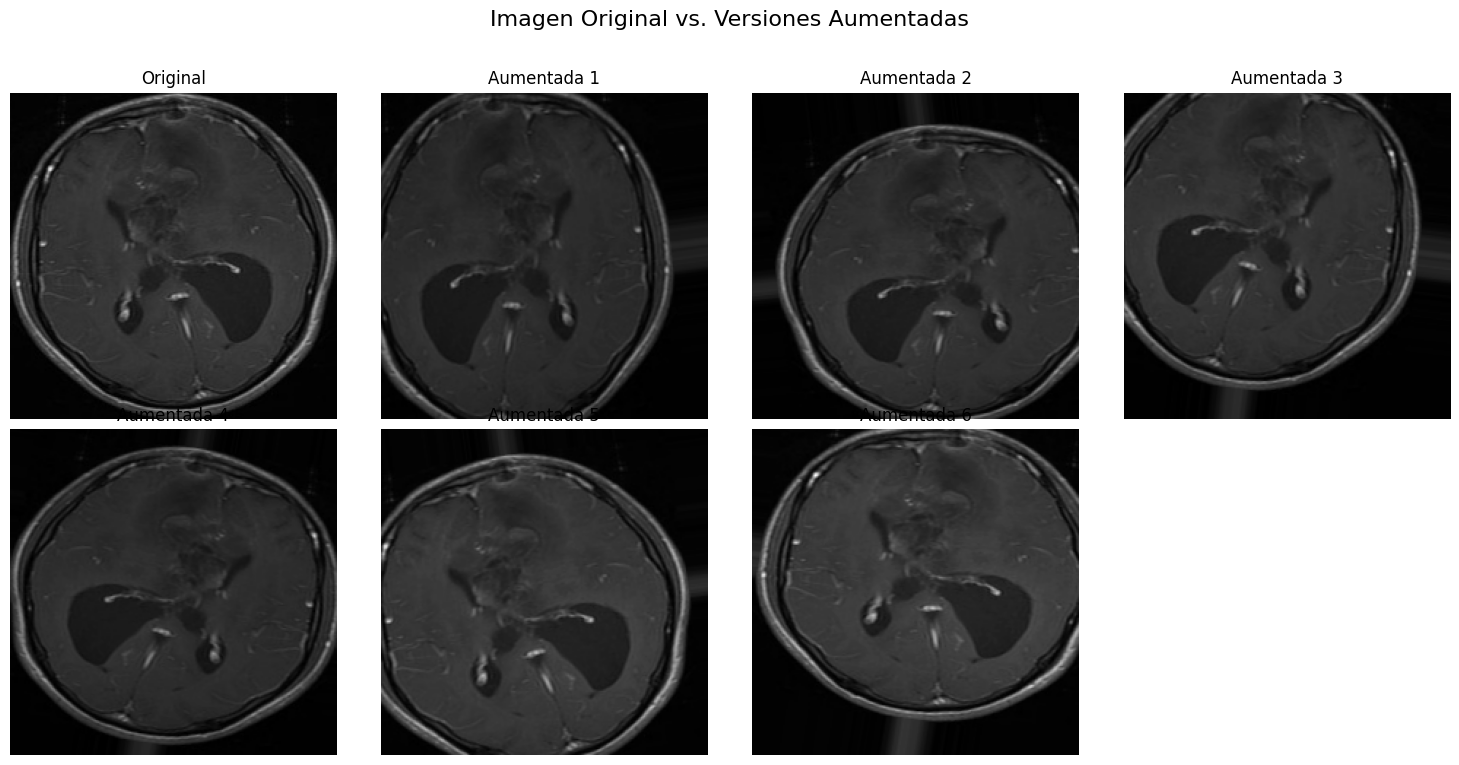

In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ruta al dataset preprocesado
preprocessed_dataset_path = '/content/preprocessed_brain_tumor_dataset'

# Seleccionar una imagen de ejemplo del conjunto de entrenamiento de cualquier clase
def get_random_preprocessed_image_path(base_path):
    training_path = os.path.join(base_path, 'Training')
    classes = [d for d in os.listdir(training_path) if os.path.isdir(os.path.join(training_path, d))]
    if not classes:
        print("Error: No se encontraron clases en el directorio de entrenamiento preprocesado.")
        return None

    random_class = np.random.choice(classes)
    class_path = os.path.join(training_path, random_class)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not images:
        print(f"Error: No se encontraron imágenes en la clase {random_class}.")
        return None
    return os.path.join(class_path, np.random.choice(images))

example_image_path = get_random_preprocessed_image_path(preprocessed_dataset_path)

if example_image_path is None:
    print("No se pudo encontrar una imagen de ejemplo para el aumento de datos.")
else:
    # Cargar la imagen de ejemplo
    original_img = cv2.imread(example_image_path) # Carga en BGR
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB) # Convertir a RGB

    # Crear un generador de aumento de datos con las especificaciones del usuario
    datagen = ImageDataGenerator(
        rotation_range=10,         # Rotación leve: ±10 grados
        width_shift_range=0.1,     # Traslación leve: hasta 10% del ancho
        height_shift_range=0.1,    # Traslación leve: hasta 10% del alto
        brightness_range=[0.8, 1.2], # Ajuste de brillo: 0.8 a 1.2
        zoom_range=0.1,            # Zoom leve: hasta 10%
        horizontal_flip=True,      # Volteo horizontal
        fill_mode='nearest'        # Rellenar píxeles nuevos con el valor más cercano
    )

    # Preparar la imagen para el generador (necesita tener forma de lote)
    img_batch = np.expand_dims(original_img, axis=0)

    # Generar 6 versiones aumentadas de la imagen
    plt.figure(figsize=(15, 8))
    plt.subplot(2, 4, 1)
    plt.imshow(original_img)
    plt.title('Original')
    plt.axis('off')

    i = 0
    for batch in datagen.flow(img_batch, batch_size=1):
        plt.subplot(2, 4, i + 2) # Empieza en el segundo subplot
        plt.imshow(batch[0].astype('uint8'))
        plt.title(f'Aumentada {i+1}')
        plt.axis('off')
        i += 1
        if i % 6 == 0: # Generar 6 imágenes aumentadas
            break

    plt.suptitle('Imagen Original vs. Versiones Aumentadas', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el super-título no se solape
    plt.show()


### Paso 9: Configuración de Generadores de Datos para Entrenamiento y Validación

Ahora que hemos visto cómo funciona el aumento de datos, crearemos los `ImageDataGenerator` para preparar nuestros conjuntos de entrenamiento y validación. Estos generadores reescalarán las imágenes y aplicarán las transformaciones de aumento de datos al conjunto de entrenamiento de forma dinámica.

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ruta al dataset preprocesado
preprocessed_dataset_path = '/content/preprocessed_brain_tumor_dataset'

# Tamaño de las imágenes y del lote
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Generador para el conjunto de entrenamiento con aumento de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Normalizar píxeles a [0, 1]
    rotation_range=10,              # Rotación leve: ±10 grados
    width_shift_range=0.1,          # Traslación horizontal leve
    height_shift_range=0.1,         # Traslación vertical leve
    brightness_range=[0.8, 1.2],    # Ajuste de brillo
    zoom_range=0.1,                 # Zoom leve
    horizontal_flip=True,           # Volteo horizontal
    fill_mode='nearest'             # Estrategia para rellenar píxeles nuevos
)

# Generador para el conjunto de validación/prueba (solo reescalado)
val_datagen = ImageDataGenerator(
    rescale=1./255                  # Normalizar píxeles a [0, 1]
)

# Cargar imágenes desde los directorios usando los generadores
train_generator = train_datagen.flow_from_directory(
    os.path.join(preprocessed_dataset_path, 'Training'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(preprocessed_dataset_path, 'Testing'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Importante para asegurar que y_true y y_pred se alineen
)

print("\nGeneradores de datos configurados. Listos para el entrenamiento del modelo.")
print(f"Clases detectadas: {train_generator.class_indices}")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Generadores de datos configurados. Listos para el entrenamiento del modelo.
Clases detectadas: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


### Paso 10: Definición del Modelo Base (MobileNetV2)

In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Definir el tamaño de entrada de la imagen
IMG_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], 3) # (224, 224, 3)
NUM_CLASSES = len(train_generator.class_indices) # 4 clases

# 1. Cargar el modelo MobileNetV2 preentrenado con pesos de ImageNet
# Excluimos la capa superior (top) porque construiremos nuestra propia capa de clasificación
base_model = MobileNetV2(input_shape=IMG_SHAPE,
                         include_top=False,
                         weights='imagenet')

# Congelar las capas del modelo base para que no se reentrenen
base_model.trainable = False

# 2. Añadir la cabeza de clasificación personalizada
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reemplaza Flatten para reducir parámetros
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output_layer = Dense(NUM_CLASSES, activation='softmax')(x)

# 3. Construir el modelo final
model = Model(inputs=base_model.input, outputs=output_layer)

# Mostrar un resumen de la arquitectura del modelo
model.summary()

print("\nModelo MobileNetV2 base definido y listo.")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Modelo MobileNetV2 base definido y listo.


### Paso 11: Compilación del Modelo

In [7]:
import tensorflow as tf

# Compilar el modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Modelo compilado exitosamente.")

Modelo compilado exitosamente.


### Paso 12: Entrenamiento del Modelo

In [8]:
history = model.fit(
    train_generator,
    epochs=10, # Puedes ajustar el número de epochs
    validation_data=validation_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001)
    ]
)

print("Entrenamiento del modelo completado.")

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 111s 500ms/step - accuracy: 0.6445 - loss: 0.8805 - val_accuracy: 0.7869 - val_loss: 0.6108 - learning_rate: 1.0000e-04
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 80s 458ms/step - accuracy: 0.7954 - loss: 0.5468 - val_accuracy: 0.8138 - val_loss: 0.5424 - learning_rate: 1.0000e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 449ms/step - accuracy: 0.8341 - loss: 0.4592 - val_accuracy: 0.8231 - val_loss: 0.5137 - learning_rate: 1.0000e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 466ms/step - accuracy: 0.8480 - loss: 0.4133 - val_accuracy: 0.8087 - val_loss: 0.5238 - learning_rate: 1.0000e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 86s 494ms/step - accuracy: 0.8612 - loss: 0.3832 - val_accuracy: 0.8200 - val_loss: 0.4948 - learning_rate: 1.0000e-04
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 90s 512ms/step - accuracy: 0.8763 - loss: 0.3498 - val_accuracy: 0.8181 - val_loss: 0.5188 - learning_rate: 1.0000e-04
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 90s 5

### Paso 13: Visualizar el Historial de Entrenamiento

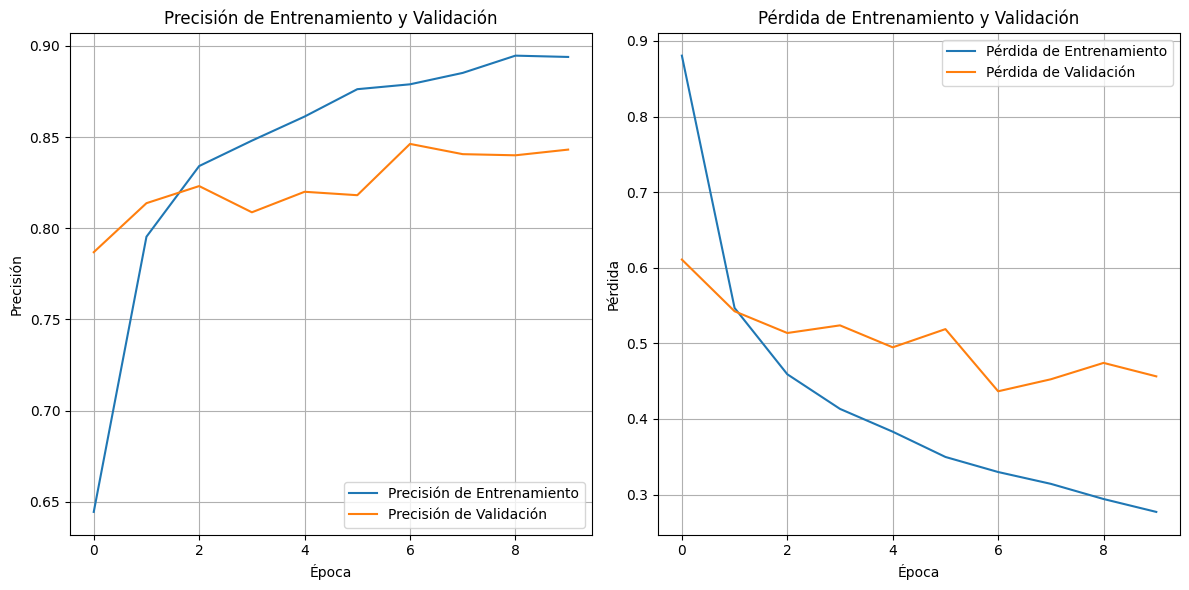

Gráficas de precisión y pérdida mostradas.


In [9]:
import matplotlib.pyplot as plt

# Obtener los datos del historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión de Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión de Validación')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True)

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida de Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida de Validación')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Gráficas de precisión y pérdida mostradas.")

### Paso 14: Evaluación del Modelo y Métricas por Clase

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.8462 - loss: 0.4366

Precisión en el conjunto de validación: 0.8462
Pérdida en el conjunto de validación: 0.4366
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step


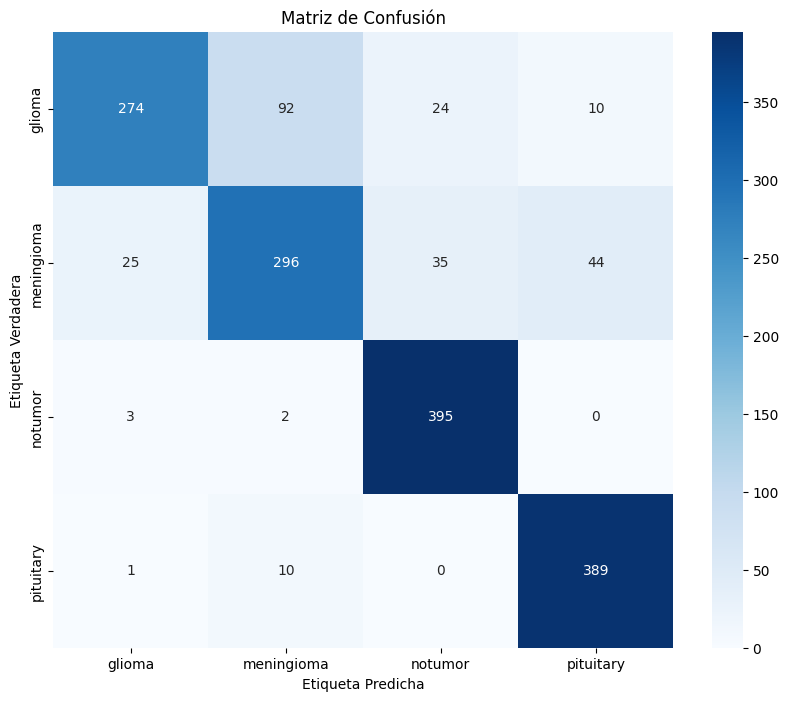

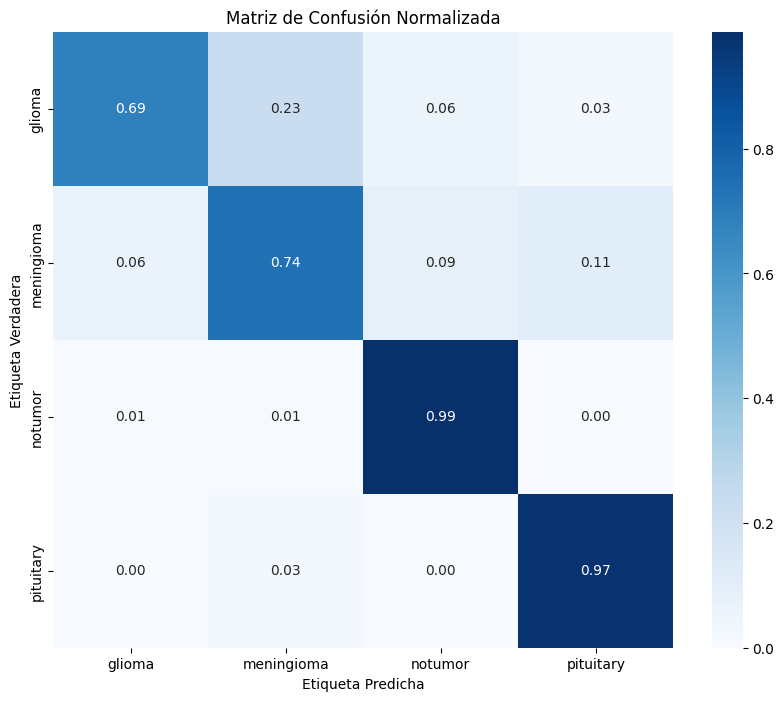


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      glioma       0.90      0.69      0.78       400
  meningioma       0.74      0.74      0.74       400
     notumor       0.87      0.99      0.93       400
   pituitary       0.88      0.97      0.92       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.84      1600
weighted avg       0.85      0.85      0.84      1600



In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Evaluar el modelo en el conjunto de validación
loss, accuracy = model.evaluate(validation_generator, verbose=1)
print(f"\nPrecisión en el conjunto de validación: {accuracy:.4f}")
print(f"Pérdida en el conjunto de validación: {loss:.4f}")

# 2. Generar predicciones para el conjunto de validación
# Necesitamos obtener las etiquetas verdaderas y las predicciones

validation_generator.reset() # Reiniciar el generador para asegurar el orden

y_true = validation_generator.classes
y_pred_probabilities = model.predict(validation_generator)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Obtener los nombres de las clases
class_names = list(validation_generator.class_indices.keys())

# 3. Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

# 4. Matriz de Confusión Normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión Normalizada')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

# 5. Reporte de Clasificación (Precision, Recall, F1-score por clase)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=class_names))

### Paso 15: Interpretabilidad del Modelo con Grad-CAM

Para interpretar las decisiones del modelo, utilizaremos **Grad-CAM (Gradient-weighted Class Activation Mapping)**. Grad-CAM produce mapas de calor que resaltan las regiones de la imagen de entrada que fueron más importantes para la predicción de una clase específica por parte del modelo.

Esto es esencial para entender si el modelo está "mirando" las áreas correctas (por ejemplo, la región del tumor) y no basando sus decisiones en ruido o características irrelevantes.

In [16]:
# Instalar tf-keras-vis para Grad-CAM
!pip install tf-keras-vis

Ahora, definiremos una función para generar y visualizar los mapas de calor de Grad-CAM. Necesitaremos:
1.  Una imagen de entrada.
2.  La predicción de la clase para esa imagen.
3.  El mapa de calor de Grad-CAM.
4.  La superposición del mapa de calor sobre la imagen original.

### Leyenda del Heatmap de Grad-CAM

*   **Colores Cálidos (rojo, naranja):** Indican las regiones de la imagen que tuvieron la **mayor influencia o importancia** en la predicción de la clase por parte del modelo. Cuanto más intenso el color cálido, mayor es la contribución de esos píxeles a la decisión del modelo.
*   **Colores Fríos (azul, verde):** Indican las regiones que tuvieron **poca o ninguna influencia** en la predicción del modelo para la clase específica. Estos píxeles no fueron considerados relevantes por el modelo para su decisión.

En resumen, el heatmap nos muestra **"dónde está mirando"** el modelo para hacer su predicción, permitiéndonos verificar si se enfoca en las características correctas (por ejemplo, el área del tumor en una imagen de resonancia magnética).


Demostración de Grad-CAM con imágenes aleatorias del conjunto de validación:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Imagen: Te-pi_355.jpg
Clase Predicha: pituitary (77.13% confianza)
Usando la capa objetivo: out_relu


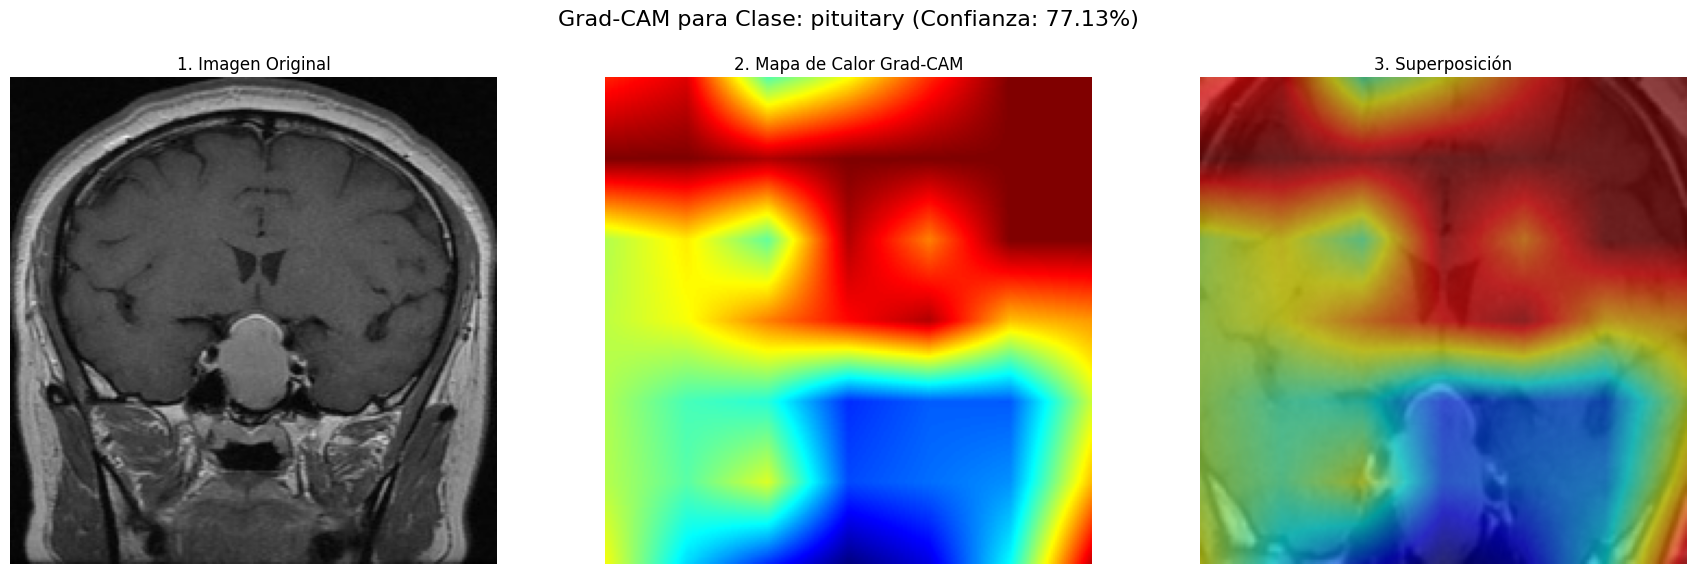


---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Imagen: Te-no_249.jpg
Clase Predicha: meningioma (68.13% confianza)
Usando la capa objetivo: out_relu


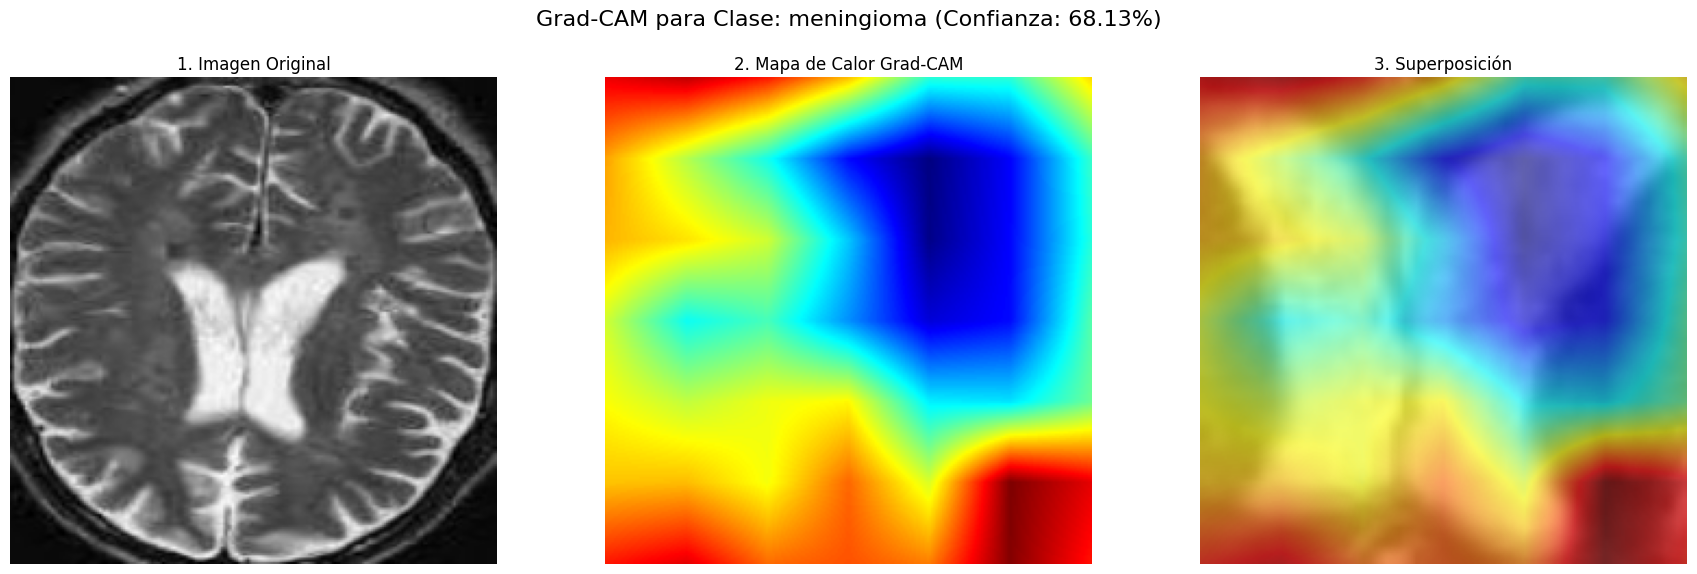


---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Imagen: Te-me_129.jpg
Clase Predicha: notumor (96.82% confianza)
Usando la capa objetivo: out_relu


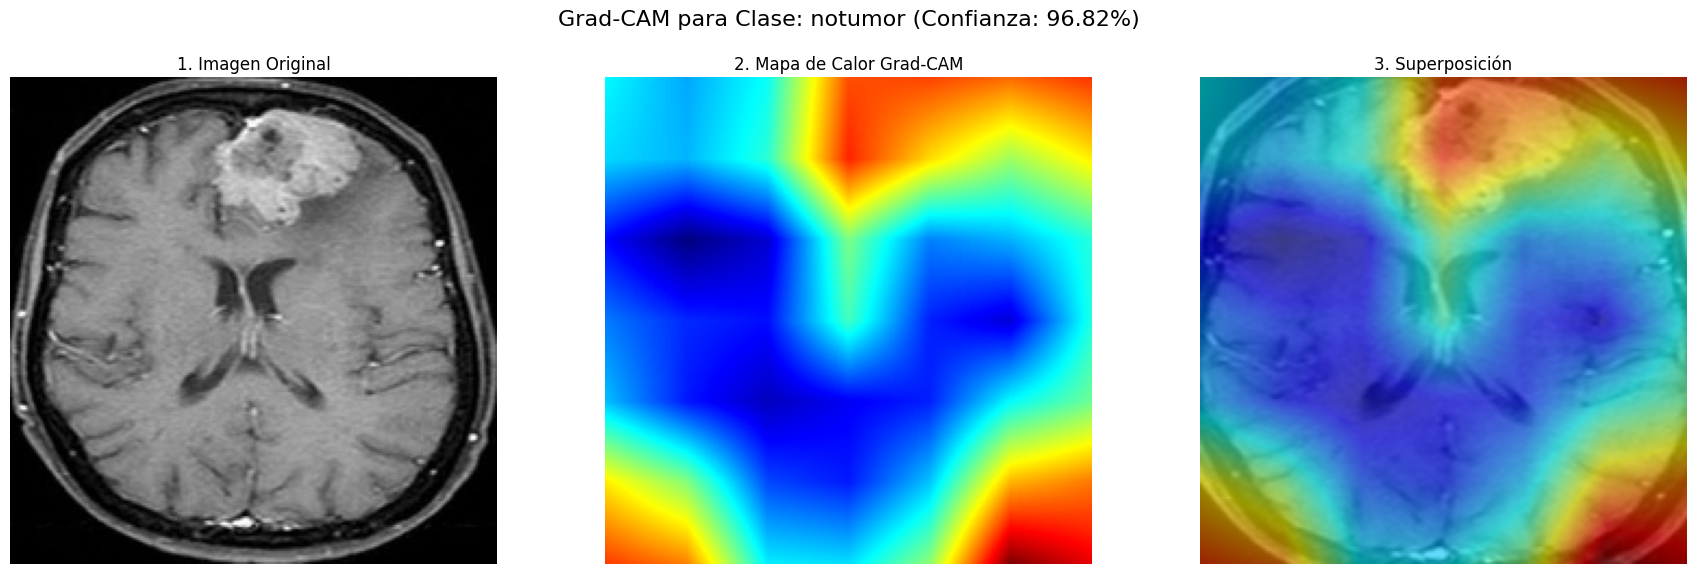


---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Imagen: Te-gl_204.jpg
Clase Predicha: notumor (96.32% confianza)
Usando la capa objetivo: out_relu


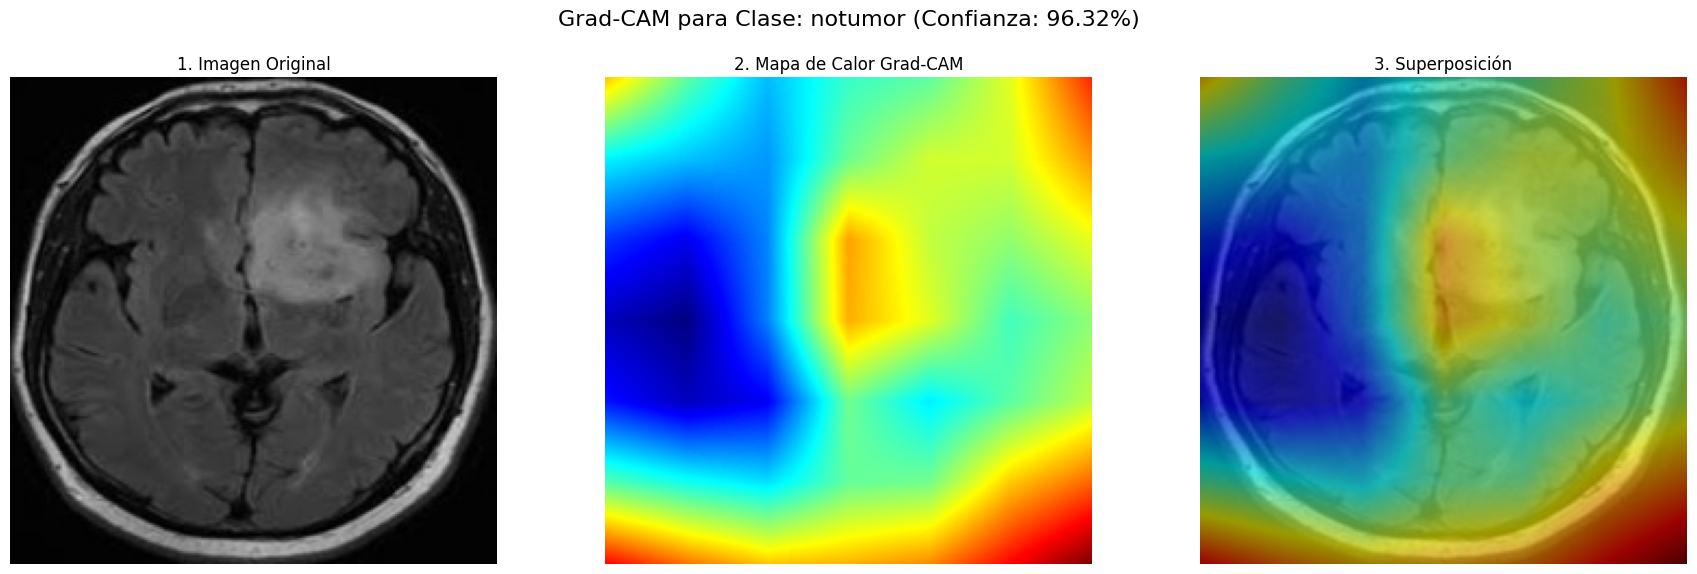

In [22]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
import tensorflow as tf

# Obtener los nombres de las clases (asegurando el orden)
class_names_ordered = [k for k, v in sorted(validation_generator.class_indices.items(), key=lambda item: item[1])]

def display_gradcam(model, image_path, class_names, target_layer_name=None, alpha=0.6):
    """
    Muestra la imagen original, el mapa de calor de Grad-CAM y la superposición.
    """
    # Cargar y preprocesar la imagen (como lo haría el ImageDataGenerator)
    img = cv2.imread(image_path) # Cargar en BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convertir a RGB
    img_display = img.copy() # Copia para mostrar el original sin escalar

    # Aplicar el preprocesamiento de la función `preprocess_image`
    preprocessed_img = preprocess_image(image_path, target_size=IMAGE_SIZE)
    if preprocessed_img is None:
        print(f"Error al preprocesar la imagen {image_path}")
        return

    # Normalizar la imagen preprocesada para el modelo (como lo hace el generador)
    input_img = preprocessed_img / 255.0 # Normalizar a [0, 1]
    input_img = np.expand_dims(input_img, axis=0) # Añadir dimensión de lote

    # Predicción del modelo
    preds = model.predict(input_img)
    predicted_class_idx = np.argmax(preds[0])
    predicted_class_name = class_names[predicted_class_idx]
    prediction_confidence = preds[0][predicted_class_idx] * 100

    print(f"Imagen: {os.path.basename(image_path)}")
    print(f"Clase Predicha: {predicted_class_name} ({prediction_confidence:.2f}% confianza)")

    # Definir la capa objetivo para Grad-CAM
    if target_layer_name is None:
        # Para MobileNetV2, 'out_relu' es la capa de activación después del último bloque convolucional.
        # Es un buen candidato para la capa 'penultimate' en Grad-CAM.
        try:
            target_layer_name = base_model.get_layer("out_relu").name
        except ValueError:
            raise ValueError("No se pudo encontrar la capa 'out_relu' en el modelo base. "
                             "Por favor, especifica manualmente 'target_layer_name' o verifica la arquitectura de MobileNetV2.")

    print(f"Usando la capa objetivo: {target_layer_name}")

    # Crear la instancia de Gradcam
    gradcam = Gradcam(model,
                      model_modifier=ReplaceToLinear(),
                      clone=True)

    # Crear el score para la clase predicha
    score = CategoricalScore(predicted_class_idx)

    # Generar el mapa de calor de Grad-CAM
    cam = gradcam(score, input_img,
                  penultimate_layer=target_layer_name)

    # Escalar el mapa de calor a las dimensiones de la imagen original y normalizar
    heatmap = cam[0, :, :]
    # Redimensionar el heatmap a las dimensiones de la imagen *preprocesada* antes de superponer
    heatmap_resized = cv2.resize(heatmap, (preprocessed_img.shape[1], preprocessed_img.shape[0]))

    # Normalizar el heatmap para visualizar
    heatmap_normalized = (heatmap_resized - np.min(heatmap_resized)) / (np.max(heatmap_resized) - np.min(heatmap_resized) + 1e-10)
    heatmap_normalized = np.uint8(255 * heatmap_normalized)
    heatmap_colored = cv2.applyColorMap(heatmap_normalized, cv2.COLORMAP_JET)

    # Superponer el heatmap sobre la imagen original
    # Asegurarse de que la imagen original para la superposición esté preprocesada y en formato RGB
    # Usamos la imagen preprocesada pero *no* normalizada [0, 255] y en RGB para la superposición
    superimposed_img = heatmap_colored * alpha + preprocessed_img * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)

    # Visualizar
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Grad-CAM para Clase: {predicted_class_name} (Confianza: {prediction_confidence:.2f}%)", fontsize=16)

    axes[0].imshow(img_display)
    axes[0].set_title('1. Imagen Original')
    axes[0].axis('off')

    axes[1].imshow(heatmap_colored)
    axes[1].set_title('2. Mapa de Calor Grad-CAM')
    axes[1].axis('off')

    axes[2].imshow(superimposed_img)
    axes[2].set_title('3. Superposición')
    axes[2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- DEMOSTRACIÓN DE USO ---
# Seleccionar una imagen de ejemplo del conjunto de validación para demostración
# Primero, obtengamos las rutas de algunas imágenes de validación
validation_paths = []
preprocessed_validation_path = os.path.join('/content/preprocessed_brain_tumor_dataset', 'Testing')
for class_name in os.listdir(preprocessed_validation_path):
    class_path = os.path.join(preprocessed_validation_path, class_name)
    if os.path.isdir(class_path):
        images = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            validation_paths.append(random.choice(images)) # Elige una imagen aleatoria por clase

if validation_paths:
    print("\nDemostración de Grad-CAM con imágenes aleatorias del conjunto de validación:")
    for i, img_path in enumerate(validation_paths):
        display_gradcam(model, img_path, class_names_ordered)
        if i < len(validation_paths) - 1:
            print("\n---\n")
else:
    print("No se encontraron imágenes en el conjunto de validación para la demostración de Grad-CAM.")